# **Reducing Model Complexity and Feature Selection**

Reducing model complexity is an essential step to prevent overfitting (high variance), which happens when a model fits training data too closely and fails to generalize to new data. Two common methods for solving this are implementing **L1 regularization** to penalize large weights and create sparse models, and applying **dimensionality reduction** techniques like Sequential Backward Selection to remove irrelevant features.

### **1. L1 Regularization and Sparsity**

L1 regularization reduces model complexity by adding a penalty equal to the sum of the absolute values of the weights. Geometrically, this penalty forms a "diamond-shaped" constraint; because the contours of the loss function are sharp, the optimum intersection point often lands exactly on the axes, driving irrelevant feature weights down to zero and yielding a sparse solution.

* **Algorithm compatibility:** When using L1 regularization in scikit-learn's LogisticRegression, you must select a compatible optimization algorithm like solver='liblinear', as the default lbfgs does not support it.

* **Controlling strength:** The parameter C is the inverse of the regularization strength. Decreasing C increases the penalization effect, making the model sparser.

In [ ]:
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                       'ml/machine-learning-databases/'
                       'wine/wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol',
                    'Malic acid', 'Ash',
                    'Alcalinity of ash', 'Magnesium',
                    'Total phenols', 'Flavanoids',
                    'Nonflavanoid phenols',
                    'Proanthocyanins',
                    'Color intensity', 'Hue',
                    'OD280/OD315 of diluted wines',
                    'Proline']

In [ ]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=0,
                                                    stratify=y)


In [ ]:
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()

X_train_std = stdsc.fit_transform(X_train)
X_test_std  = stdsc.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Note that C=1.0 is the default. Decrease it to make the regularization effect stronger.
lr = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', multi_class='ovr')

lr.fit(X_train_std, y_train)

print('Training accuracy:', lr.score(X_train_std, y_train))
print("\n")

print('Test accuracy:', lr.score(X_test_std, y_test))
print("\n")

# Accessing the bias unit (intercept)
print(lr.intercept_)
print("\n")

# Accessing the weight coefficients to observe sparsity (zeros)
print(lr.coef_)
print("\n")

Training accuracy: 1.0


Test accuracy: 1.0


[-1.2634354  -1.21591844 -2.37039916]


[[ 1.24607601  0.18014631  0.74589385 -1.16353131  0.          0.
   1.1616385   0.          0.          0.          0.          0.55590149
   2.50947777]
 [-1.53616612 -0.38798338 -0.9951002   0.36533483 -0.05977888  0.
   0.66781995  0.          0.         -1.93468423  1.23288388  0.
  -2.23095633]
 [ 0.13585943  0.16832573  0.35721871  0.          0.          0.
  -2.43836886  0.          0.          1.56345825 -0.81878678 -0.49240024
   0.        ]]




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### **2. Visualizing the Regularization Path**

By training models across a range of regularization strengths (varying the C parameter), you can plot a regularization path to visualize how individual feature weights shrink to zero as the penalty increases.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

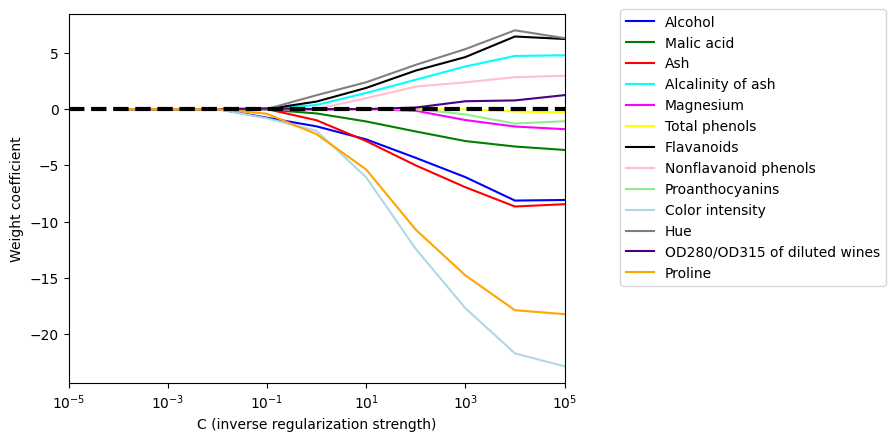

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

fig = plt.figure()
ax = plt.subplot(111)
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black',
          'pink', 'lightgreen', 'lightblue', 'gray', 'indigo', 'orange']

weights, params = [], []

for c in np.arange(-4., 6.):
    lr = LogisticRegression(penalty='l1', C=10.**c, solver='liblinear',
                            multi_class='ovr', random_state=0)
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10**c)

weights = np.array(weights)

for column, color in zip(range(weights.shape[1]), colors):
    plt.plot(params, weights[:, column], label=df_wine.columns[column + 1], color=color)

plt.axhline(0, color='black', linestyle='--', linewidth=3)
plt.xlim([10**(-5), 10**5])
plt.ylabel('Weight coefficient')
plt.xlabel('C (inverse regularization strength)')
plt.xscale('log')
plt.legend(loc='upper left')
ax.legend(loc='upper center', bbox_to_anchor=(1.38, 1.03), ncol=1, fancybox=True)
plt.show()

### **3. Sequential Backward Selection (SBS)**

Sequential feature selection algorithms reduce dimensionality by automatically finding subsets of highly relevant features. Sequential Backward Selection (SBS) is a greedy search algorithm that functions through the following steps:

1. Initialize the algorithm with the full feature space.

2. Identify the single feature that, when removed, causes the least performance loss.

3. Remove that feature from the subset.

4. Repeat until the subset matches the target number of features.

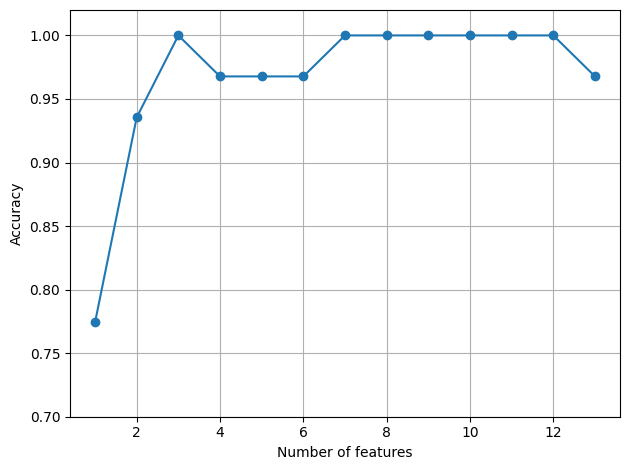

In [ ]:
from sklearn.base import clone
from itertools import combinations
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

class SBS:
    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state)

        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1
            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score

# Applying the SBS algorithm to a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_features=1)
sbs.fit(X_train_std, y_train)

# Plotting the performance of feature subsets
k_feat = [len(k) for k in sbs.subsets_]
plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylim([0.7, 1.02])
plt.ylabel('Accuracy')
plt.xlabel('Number of features')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Extracting the best 3-feature subset
k3 = list(sbs.subsets_[10])
print(df_wine.columns[1:][k3])

Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='object')


In [ ]:
# Evaluating the reduced model vs the full model
knn.fit(X_train_std, y_train)
print('Training accuracy:', knn.score(X_train_std, y_train))
print('Test accuracy:', knn.score(X_test_std, y_test))

Training accuracy: 0.967741935483871
Test accuracy: 0.9629629629629629


In [ ]:
# Evaluating the reduced model vs the full model
knn.fit(X_train_std[:, k3], y_train)
print('Training accuracy:', knn.score(X_train_std[:, k3], y_train))
print('Test accuracy:', knn.score(X_test_std[:, k3], y_test))

Training accuracy: 0.9516129032258065
Test accuracy: 0.9259259259259259


**Feature Selection:** https://scikit-learn.org/stable/modules/feature_selection.html